In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering

In [9]:
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [10]:
np.random.seed(42)

In [11]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))

# Быстрый refresh данных, чтобы ноутбук был воспроизводимым

In [12]:
# Feature Engineering v1 (13 признаков)
def extract_features(signal):
    s = 2**14 - np.array(signal) - 1560
    features = {}
    features['baseline'] = np.mean(s[:50])
    features['peak_amplitude'] = np.max(s) - features['baseline']
    peak_idx = np.argmax(s)
    features['peak_position'] = peak_idx
    threshold_10 = features['baseline'] + 0.1 * features['peak_amplitude']
    threshold_90 = features['baseline'] + 0.9 * features['peak_amplitude']
    rise_start = np.where(s[:peak_idx] >= threshold_10)[0]
    rise_end = np.where(s[:peak_idx] >= threshold_90)[0]
    features['rise_time'] = (rise_end[0] - rise_start[0]) if len(rise_start) > 0 and len(rise_end) > 0 else 0
    fall_start = np.where(s[peak_idx:] <= threshold_90)[0]
    fall_end = np.where(s[peak_idx:] <= threshold_10)[0]
    features['fall_time'] = (fall_end[0] - fall_start[0]) if len(fall_start) > 0 and len(fall_end) > 0 else 0
    features['width_50'] = np.sum(s > (features['baseline'] + 0.5 * features['peak_amplitude']))
    features['total_integral'] = np.sum(s - features['baseline'])
    features['integral_peak'] = np.sum(s[max(0, peak_idx-10):min(500, peak_idx+10)] - features['baseline'])
    features['skewness'] = stats.skew(s)
    features['kurtosis'] = stats.kurtosis(s)
    features['rise_fall_ratio'] = features['rise_time'] / (features['fall_time'] + 1)
    features['peak_to_integral'] = features['peak_amplitude'] / (features['total_integral'] + 1)
    features['asymmetry'] = np.sum(s[:peak_idx]) / (np.sum(s[peak_idx:]) + 1)
    return features

features_list = []
for i in range(len(dataset)):
    features_list.append(extract_features(dataset.iloc[i]))
df_features = pd.DataFrame(features_list)

selected_features = ['baseline', 'peak_amplitude', 'peak_position', 'rise_time', 
                     'fall_time', 'width_50', 'skewness', 'peak_to_integral', 'asymmetry']
X_selected = df_features[selected_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Копия блока бейзлайна K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

unique, counts = np.unique(labels_kmeans, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(labels_kmeans)*100:.1f}%)")

  Кластер 0: 8607 сигналов (36.7%)
  Кластер 1: 9832 сигналов (41.9%)
  Кластер 2: 5040 сигналов (21.5%)


In [14]:
sil = silhouette_score(X_scaled, labels_kmeans, sample_size=5000)
db = davies_bouldin_score(X_scaled, labels_kmeans)
ch = calinski_harabasz_score(X_scaled, labels_kmeans)
print(f"Silhouette score: {sil:.4f}")
print(f"Davies-Bouldin score: {db:.4f} * the lower the better")
print(f"Calinski-Harabasz score: {ch:.1f} * the lower the worst")

Silhouette score: 0.2436
Davies-Bouldin score: 1.5365 * the lower the better
Calinski-Harabasz score: 6666.3 * the lower the worst


# Иерархическая кластеризация и DBSCAN

- Agglomerative Clustering (иерархический) — не требует задания числа кластеров заранее

In [15]:
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)

unique, counts = np.unique(labels_agg, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(labels_agg)*100:.1f}%)")

sil_agg = silhouette_score(X_scaled, labels_agg, sample_size=5000)
db_agg = davies_bouldin_score(X_scaled, labels_agg)
ch_agg = calinski_harabasz_score(X_scaled, labels_agg)

print(f"  Silhouette: {sil_agg:.4f}")
print(f"  Davies-Bouldin: {db_agg:.4f}")
print(f"  Calinski-Harabasz: {ch_agg:.1f}")

  Кластер 0: 11239 сигналов (47.9%)
  Кластер 1: 12239 сигналов (52.1%)
  Кластер 2: 1 сигналов (0.0%)
  Silhouette: 0.2568
  Davies-Bouldin: 1.0029
  Calinski-Harabasz: 6102.3


Сравнение с k-means:

In [16]:
print(f"Silhouette: K-means={sil:.4f}, Agglomerative={sil_agg:.4f}")
print(f"DB: K-means={db:.4f}, Agglomerative={db_agg:.4f}")
print(f"CH: K-means={ch:.1f}, Agglomerative={ch_agg:.1f}")

Silhouette: K-means=0.2436, Agglomerative=0.2568
DB: K-means=1.5365, Agglomerative=1.0029
CH: K-means=6666.3, Agglomerative=6102.3


Agglomerative дал 1 сигнал в кластере 2 — это явно неправильно, модель не справилась с k=3 на таком объёме данных.

- DBSCAN не очень хорошая идея, но и его проверим.

    - надо подобрать параметры, т.к. DBSCAN чувствителен к eps --> поиск оптимального eps через k-distance график

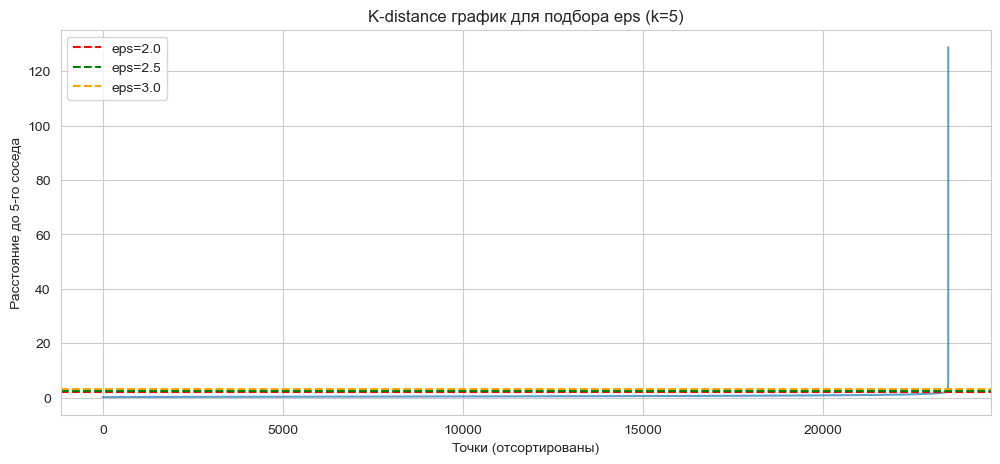

In [17]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(12, 5))
plt.plot(k_dist, alpha=0.7)
plt.axhline(y=2.0, color='r', linestyle='--', label='eps=2.0')
plt.axhline(y=2.5, color='g', linestyle='--', label='eps=2.5')
plt.axhline(y=3.0, color='orange', linestyle='--', label='eps=3.0')
plt.xlabel('Точки (отсортированы)')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('K-distance график для подбора eps (k=5)')
plt.legend()
plt.show()

In [18]:
for eps_val in [2.0, 2.5, 3.0]:
    dbscan = DBSCAN(eps=eps_val, min_samples=10)
    labels_db = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = np.sum(labels_db == -1)
    print(f"  eps={eps_val}: найдено кластеров={n_clusters}, шум={n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

  eps=2.0: найдено кластеров=1, шум=41 (0.2%)
  eps=2.5: найдено кластеров=1, шум=16 (0.1%)
  eps=3.0: найдено кластеров=1, шум=9 (0.0%)


Итог:

DBSCAN видит все данные как 1 кластер (при любом из рассмотренных eps) -->  в пространстве признаков нет разрывов — данные образуют единое связное облако. Даже шум — это мизерная доля (<0.2%), а при eps=3.0 шума нет вообще.

Вывод:

- Реально данных — один плотный кластер с очень слабой внутренней неоднородностью.
    - K‑means искусственно режет его на 2–3 куска, которые немного отличаются по центроидам, но перекрываются.
    - DBSCAN честно показывает: «разрывов нет».

Дендрограмма на подвыборке (полный датасет слишком большой)

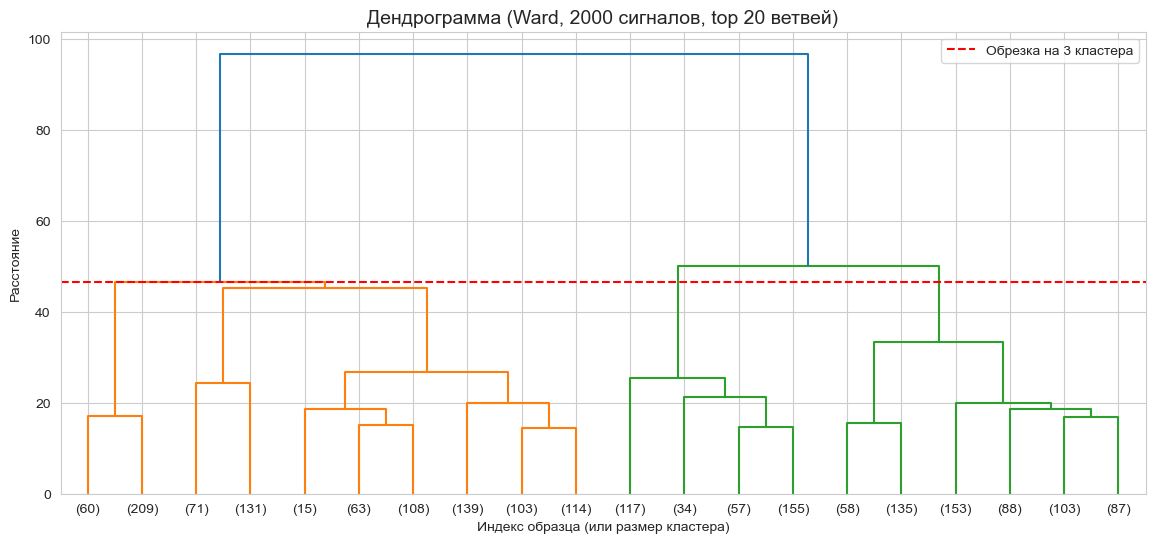

In [19]:
sample_dendro = np.random.choice(len(X_scaled), 2000, replace=False)
X_dendro = X_scaled[sample_dendro]

plt.figure(figsize=(14, 6))
linkage_matrix = linkage(X_dendro, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_font_size=10)
plt.title('Дендрограмма (Ward, 2000 сигналов, top 20 ветвей)', fontsize=14)
plt.xlabel('Индекс образца (или размер кластера)')
plt.ylabel('Расстояние')
plt.axhline(y=linkage_matrix[-3, 2], color='r', linestyle='--', label='Обрезка на 3 кластера')
plt.legend()
plt.show()

- Видим, что если обрезать на 3 кластера, то они будут нестабильны (чуть изменишь высоту отсечки — и состав кластеров резко меняется).
    - -> отсутствие реальной кластерной структуры.

Итог:
- данные не кластеризуются естественным образом. Это единое, связное облако точек.
    - K‑means выдаёт 2–3 кластера только потому, что его заставляют их искать.
    - DBSCAN + дендрограмма + t‑SNE/UMAP показывают, что настоящих явных разделений нет.

# Gaussian Mixture Model и сравнение всех моделей

Gaussian Mixture Model лучше работает с перекрывающимися кластерами, потому что использует вероятностный подход.

In [20]:
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
labels_gmm = gmm.fit_predict(X_scaled)

unique, counts = np.unique(labels_gmm, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f"  Кластер {cl}: {cnt} сигналов ({cnt/len(labels_gmm)*100:.1f}%)")

sil_gmm = silhouette_score(X_scaled, labels_gmm, sample_size=5000)
db_gmm = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm = calinski_harabasz_score(X_scaled, labels_gmm)

print(f"  Silhouette: {sil_gmm:.4f}")
print(f"  Davies-Bouldin: {db_gmm:.4f}")
print(f"  Calinski-Harabasz: {ch_gmm:.1f}")

  Кластер 0: 14780 сигналов (62.9%)
  Кластер 1: 7456 сигналов (31.8%)
  Кластер 2: 1243 сигналов (5.3%)
  Silhouette: 0.1579
  Davies-Bouldin: 1.8715
  Calinski-Harabasz: 2688.0


Сравнение GMM с K-means

In [21]:
print(f"  Silhouette: GMM={sil_gmm:.4f}, K-means={sil:.4f}")
print(f"  DB: GMM={db_gmm:.4f}, K-means={db:.4f}")
print(f"  CH: GMM={ch_gmm:.1f}, K-means={ch:.1f}")

  Silhouette: GMM=0.1579, K-means=0.2436
  DB: GMM=1.8715, K-means=1.5365
  CH: GMM=2688.0, K-means=6666.3


Микро-вывод по кластеризации:

- Agglomerative — провал (не работает с большими данными)
- DBSCAN - провал, выделил только 1 кластер

- GMM — сливает два кластера в один огромный (62.9%), а третий слишком мал (5.3%)

- K-means — даёт наиболее сбалансированное разделение: ~37%, ~42%, ~21% — что физически соответствует двум типам частиц + аномалии



Вывод: прямые методы кластеризации не справляются с этой задачей.
Данные не имеют естественных разрывов между классами — граница между гамма и нейтронами
определяется физикой взаимодействия частиц с детектором, а не геометрией облака точек.

Нужно использовать физически обоснованные признаки (charge comparison)
и двухэтапный подход: сначала выделить аномалии, потом разделить нормальные сигналы по форме хвоста.